# Importing libraries

In [575]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import scipy.stats as stats
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from sklearn.metrics import roc_auc_score
import statsmodels.api as sm

# Data loading

In [576]:
df = pd.read_csv("AirbnbEurope.csv")

# Filling missing values

In [577]:
df = df[df['price'].notnull()].copy()

In [578]:
# Missing values here occur when 'number_of_reviews' is 0, so 0 is factually correct.
df['reviews_per_month'] = df['reviews_per_month'].fillna(0)

# Ratings are often skewed; the median provides a "typical" score without being pulled by outliers.
df['review_scores_rating'] = df['review_scores_rating'].fillna(df['review_scores_rating'].median())

# Fill bathrooms, bedrooms, beds nulls based on 'accommodates' group median, then global median
df['bathrooms'] = df.groupby('accommodates')['bathrooms'].transform(lambda x: x.fillna(x.median()))
df['bathrooms'] = df['bathrooms'].fillna(df['bathrooms'].median())

df['bedrooms'] = df.groupby('accommodates')['bedrooms'].transform(lambda x: x.fillna(x.median()))
df['bedrooms'] = df['bedrooms'].fillna(df['bedrooms'].median())

df['beds'] = df.groupby('accommodates')['beds'].transform(lambda x: x.fillna(x.median()))
df['beds'] = df['beds'].fillna(df['beds'].median())

# # Fill price using median
# df['price'] = df['price'].fillna(df['price'].median())

# Since log_price is a mathematical derivative of price, we recalculate it to ensure consistency.
df['log_price'] = np.log1p(df['price'])

# Fill Host Info (Small number of missing values)
df['host_since'] = df['host_since'].fillna(df['host_since'].mode()[0])
df['host_total_listings_count'] = df['host_total_listings_count'].fillna(df['host_total_listings_count'].median())
df["host_tenure_days"] = df["host_tenure_days"].abs()
df['host_tenure_days'] = df['host_tenure_days'].fillna(df['host_tenure_days'].median())


In [579]:
# inroduce variable distance to city center (calculate distance using latitude and longitude)
# city centers coordinates for distance calculation
cities_coords = {
    'amsterdam': {'latitude': 52.3791, 'longitude': 4.9003}, 
    'athens': {'latitude': 37.9657, 'longitude': 23.7391}, 
    'barselona': {'latitude': 41.3851, 'longitude': 2.1734}, 
    'berlin': {'latitude': 52.52, 'longitude': 13.405}, 
    'copenhagen': {'latitude': 55.6761, 'longitude': 12.5683}, 
    'london': {'latitude': 51.5074, 'longitude': 0.1272}, 
    'prague': {'latitude': 50.0755, 'longitude': 14.4378}, 
    'rome': {'latitude': 41.9029, 'longitude': 12.4964}, 
    'stockholm': {'latitude': 59.3293, 'longitude': 18.0686}, 
    'vienna': {'latitude': 48.2336, 'longitude': 16.4171}
}

# calculate distance from each listing to city center
def haversine_distance(lat1, lon1, lat2, lon2):
    R = 6371  # Earth radius in kilometers
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    delta_phi = np.radians(lat2 - lat1)
    delta_lambda = np.radians(lon2 - lon1)
    
    a = np.sin(delta_phi / 2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda / 2)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))
    
    return R * c

distances = []
for index, row in df.iterrows():
    city = row['city']
    if city in cities_coords:
        city_lat = cities_coords[city]['latitude']
        city_lon = cities_coords[city]['longitude']
        distance = haversine_distance(row['latitude'], row['longitude'], city_lat, city_lon)
        distances.append(distance)
    else:
        distances.append(np.nan)  # If city is not in the list, assign NaN

df['distance_to_city_center'] = distances
df['distance_to_city_center'] = df['distance_to_city_center'].fillna(df['distance_to_city_center'].median())

print(df.isnull().sum())


listing_id                   0
host_since                   0
host_is_superhost            0
host_total_listings_count    0
neighbourhood_cleansed       0
latitude                     0
longitude                    0
property_type                0
room_type                    0
accommodates                 0
bathrooms                    0
bedrooms                     0
beds                         0
price                        0
minimum_nights               0
availability_365             0
number_of_reviews            0
review_scores_rating         0
instant_bookable             0
reviews_per_month            0
host_tenure_days             0
occupancy                    0
reviews_last_year            0
city                         0
log_price                    0
distance_to_city_center      0
dtype: int64


# Working with outliers

## Old dataframe (finding outliers)

Number of outliers: 1231


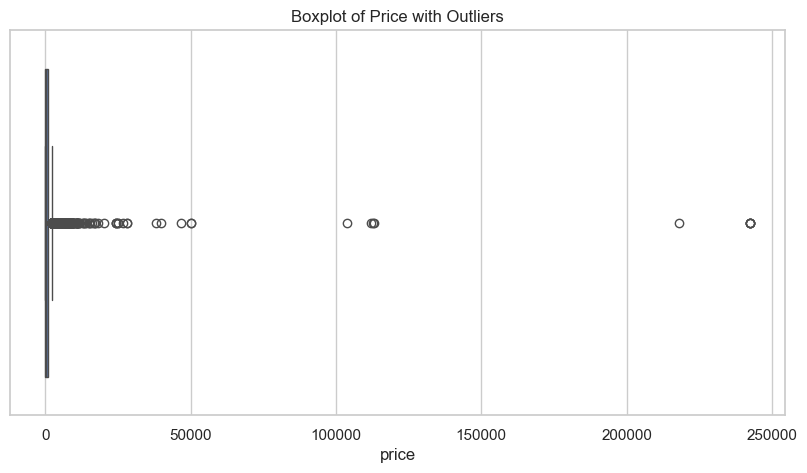

In [580]:
def get_outliers_info(df, column_name):
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = df[(df[column_name] < lower_bound) | (df[column_name] > upper_bound)]
    
    print(f"Number of outliers: {len(outliers)}")
    
    return outliers, (lower_bound, upper_bound)

price_outliers, bounds = get_outliers_info(df, 'price')

plt.figure(figsize=(10, 5))
sns.boxplot(x=df['price'])
plt.title('Boxplot of Price with Outliers')
plt.show()

## New dataframe (deleting outliers)

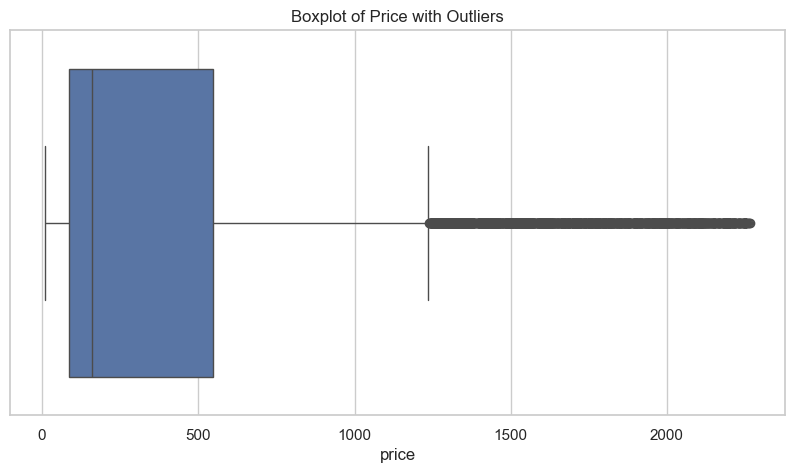

In [581]:
Q1 = df['price'].quantile(0.25)
Q3 = df['price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['price'] >= lower_bound) & (df['price'] <= upper_bound)].copy()

df.to_csv('new_one.csv', index=False)

plt.figure(figsize=(10, 5))
sns.boxplot(x=df['price'])
plt.title('Boxplot of Price with Outliers')
plt.show()

In [582]:
df.to_csv('new_one.csv', index=False)
df = pd.read_csv('new_one.csv')

# Distribution for price and occupancy

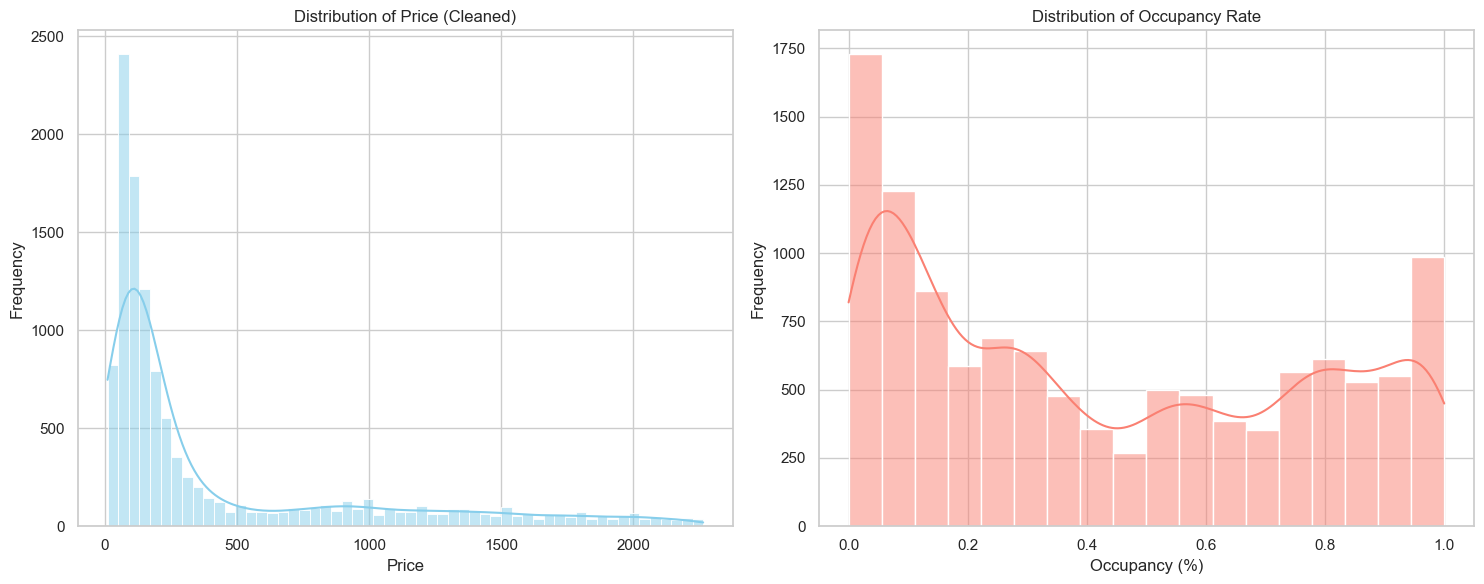

In [583]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(df['price'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Price (Cleaned)')
axes[0].set_xlabel('Price')
axes[0].set_ylabel('Frequency')

sns.histplot(df['occupancy'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Occupancy Rate')
axes[1].set_xlabel('Occupancy (%)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Creating linear models and working with assumptions

## Models for price

In [584]:
y = df['price']
cols = ["host_is_superhost", "host_total_listings_count", "host_tenure_days", "accommodates", "bathrooms", "bedrooms", "beds", "availability_365", "number_of_reviews","reviews_last_year", "review_scores_rating", "reviews_per_month", "occupancy"]
X = df[cols].copy()
X = sm.add_constant(X)

price_linlin_model = sm.OLS(y, X).fit(cov_type='HC3')
price_loglin_model = sm.OLS(np.log1p(y), X).fit(cov_type='HC3')
price_linlog_model = sm.OLS(y, np.log1p(X)).fit(cov_type='HC3')
price_loglog_model = sm.OLS(np.log1p(y), np.log1p(X)).fit(cov_type='HC3')

In [585]:
print(price_linlin_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.035
Model:                            OLS   Adj. R-squared:                  0.034
Method:                 Least Squares   F-statistic:                     30.99
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           1.37e-76
Time:                        16:06:03   Log-Likelihood:                -90943.
No. Observations:               11795   AIC:                         1.819e+05
Df Residuals:                   11781   BIC:                         1.820e+05
Df Model:                          13                                         
Covariance Type:                  HC3                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [586]:
print(price_linlog_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.035
Model:                            OLS   Adj. R-squared:                  0.034
Method:                 Least Squares   F-statistic:                     35.07
Date:                Wed, 08 Apr 2026   Prob (F-statistic):           2.00e-87
Time:                        16:06:03   Log-Likelihood:                -90943.
No. Observations:               11795   AIC:                         1.819e+05
Df Residuals:                   11781   BIC:                         1.820e+05
Df Model:                          13                                         
Covariance Type:                  HC3                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [587]:
print(price_loglin_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.058
Model:                            OLS   Adj. R-squared:                  0.057
Method:                 Least Squares   F-statistic:                     64.25
Date:                Wed, 08 Apr 2026   Prob (F-statistic):          3.67e-164
Time:                        16:06:03   Log-Likelihood:                -18109.
No. Observations:               11795   AIC:                         3.625e+04
Df Residuals:                   11781   BIC:                         3.635e+04
Df Model:                          13                                         
Covariance Type:                  HC3                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [588]:
print(price_loglog_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.059
Model:                            OLS   Adj. R-squared:                  0.058
Method:                 Least Squares   F-statistic:                     63.30
Date:                Wed, 08 Apr 2026   Prob (F-statistic):          1.08e-161
Time:                        16:06:03   Log-Likelihood:                -18102.
No. Observations:               11795   AIC:                         3.623e+04
Df Residuals:                   11781   BIC:                         3.633e+04
Df Model:                          13                                         
Covariance Type:                  HC3                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [589]:
threshold = df['price'].median()
y = (df['price'] > threshold).astype(int)

X = df[cols].copy()
X = sm.add_constant(X)

price_probability_model = sm.OLS(y, X).fit(cov_type='HC3')
print(price_probability_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.077
Model:                            OLS   Adj. R-squared:                  0.076
Method:                 Least Squares   F-statistic:                     93.97
Date:                Wed, 08 Apr 2026   Prob (F-statistic):          1.75e-240
Time:                        16:06:03   Log-Likelihood:                -8090.2
No. Observations:               11795   AIC:                         1.621e+04
Df Residuals:                   11781   BIC:                         1.631e+04
Df Model:                          13                                         
Covariance Type:                  HC3                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [590]:
price_logit_model = sm.Logit(y, X).fit(cov_type='HC3')
print(price_logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.651454
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                  price   No. Observations:                11795
Model:                          Logit   Df Residuals:                    11781
Method:                           MLE   Df Model:                           13
Date:                Wed, 08 Apr 2026   Pseudo R-squ.:                 0.06014
Time:                        16:06:03   Log-Likelihood:                -7683.9
converged:                       True   LL-Null:                       -8175.6
Covariance Type:                  HC3   LLR p-value:                6.390e-202
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        -3.2216      0.916     -3.519      0.000      -5.

## Models for occupancy

In [591]:
y = df['occupancy']

cols = ["host_is_superhost", "host_total_listings_count", "host_tenure_days", "accommodates", "bathrooms", "bedrooms", "beds", "availability_365", "number_of_reviews","reviews_last_year", "review_scores_rating", "reviews_per_month", "price"]
X = df[cols].copy()
X = sm.add_constant(X)

occ_linlin_model = sm.OLS(y, X).fit(cov_type='HC3')
occ_loglin_model = sm.OLS(np.log1p(y), X).fit(cov_type='HC3')
occ_linlog_model = sm.OLS(y, np.log1p(X)).fit(cov_type='HC3')
occ_loglog_model = sm.OLS(np.log1p(y), np.log1p(X)).fit(cov_type='HC3')

In [592]:
print(occ_linlin_model.summary())

                            OLS Regression Results                            
Dep. Variable:              occupancy   R-squared:                       0.997
Model:                            OLS   Adj. R-squared:                  0.997
Method:                 Least Squares   F-statistic:                 4.093e+06
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:06:03   Log-Likelihood:                 30435.
No. Observations:               11795   AIC:                        -6.084e+04
Df Residuals:                   11781   BIC:                        -6.074e+04
Df Model:                          13                                         
Covariance Type:                  HC3                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [593]:
print(occ_linlog_model.summary())

                            OLS Regression Results                            
Dep. Variable:              occupancy   R-squared:                       0.746
Model:                            OLS   Adj. R-squared:                  0.745
Method:                 Least Squares   F-statistic:                     839.7
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:06:03   Log-Likelihood:                 4314.2
No. Observations:               11795   AIC:                            -8600.
Df Residuals:                   11781   BIC:                            -8497.
Df Model:                          13                                         
Covariance Type:                  HC3                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [594]:
print(occ_loglin_model.summary())

                            OLS Regression Results                            
Dep. Variable:              occupancy   R-squared:                       0.990
Model:                            OLS   Adj. R-squared:                  0.990
Method:                 Least Squares   F-statistic:                 7.562e+04
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:06:03   Log-Likelihood:                 27620.
No. Observations:               11795   AIC:                        -5.521e+04
Df Residuals:                   11781   BIC:                        -5.511e+04
Df Model:                          13                                         
Covariance Type:                  HC3                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [595]:
print(occ_loglog_model.summary())

                            OLS Regression Results                            
Dep. Variable:              occupancy   R-squared:                       0.693
Model:                            OLS   Adj. R-squared:                  0.693
Method:                 Least Squares   F-statistic:                     728.1
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:06:04   Log-Likelihood:                 7462.9
No. Observations:               11795   AIC:                        -1.490e+04
Df Residuals:                   11781   BIC:                        -1.479e+04
Df Model:                          13                                         
Covariance Type:                  HC3                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [596]:
threshold = df['occupancy'].median()
y = (df['occupancy'] > threshold).astype(int)

X = df[cols].copy()
X = sm.add_constant(X)

occ_probability_model = sm.OLS(y, X).fit(cov_type='HC3')
print(occ_probability_model.summary())

                            OLS Regression Results                            
Dep. Variable:              occupancy   R-squared:                       0.778
Model:                            OLS   Adj. R-squared:                  0.778
Method:                 Least Squares   F-statistic:                     7562.
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        16:06:04   Log-Likelihood:                 326.06
No. Observations:               11795   AIC:                            -624.1
Df Residuals:                   11781   BIC:                            -520.9
Df Model:                          13                                         
Covariance Type:                  HC3                                         
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                 

In [597]:
occ_logit_model = sm.Logit(y, X).fit(cov_type='HC3')
print(occ_logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.037047
         Iterations 13
                           Logit Regression Results                           
Dep. Variable:              occupancy   No. Observations:                11795
Model:                          Logit   Df Residuals:                    11781
Method:                           MLE   Df Model:                           13
Date:                Wed, 08 Apr 2026   Pseudo R-squ.:                  0.9466
Time:                        16:06:04   Log-Likelihood:                -436.97
converged:                       True   LL-Null:                       -8175.7
Covariance Type:                  HC3   LLR p-value:                     0.000
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        43.6723     10.066      4.339      0.000      23

# Checking assumptions for models

## Heteroskedasticity

In [598]:
def heteroskedasticity_test(model):
    _, pval, _, _ = het_breuschpagan(model.resid, model.model.exog)
    print(f"p-value = {pval}")
    
    if pval < 0.05:
        print("Heteroskedasticity\n")
    else:
        print("Homoscedasticity\n")

In [599]:
heteroskedasticity_test(price_linlin_model)
heteroskedasticity_test(price_loglin_model)
heteroskedasticity_test(price_linlog_model)
heteroskedasticity_test(price_loglog_model)
heteroskedasticity_test(occ_linlin_model)
heteroskedasticity_test(occ_loglin_model)
heteroskedasticity_test(occ_linlog_model)
heteroskedasticity_test(occ_loglog_model)

p-value = 1.5093086277120738e-42
Heteroskedasticity

p-value = 4.652055774510222e-81
Heteroskedasticity

p-value = 2.7150149819491747e-48
Heteroskedasticity

p-value = 2.5529295814771974e-89
Heteroskedasticity

p-value = 0.0018508183264188491
Heteroskedasticity

p-value = 0.005864076571242419
Heteroskedasticity

p-value = 0.0
Heteroskedasticity

p-value = 0.0
Heteroskedasticity



## Linearity

In [600]:
def linearity_test(model):
    _, pval = sm.stats.linear_rainbow(model)
    print(f"p-value = {pval}")
    
    if pval < 0.05:
        print("Bad linearity\n")
    else:
        print("Good linearity\n")

In [601]:
linearity_test(price_linlin_model)
linearity_test(price_loglin_model)
linearity_test(price_linlog_model)
linearity_test(price_loglog_model)
linearity_test(occ_linlin_model)
linearity_test(occ_loglin_model)
linearity_test(occ_linlog_model)
linearity_test(occ_loglog_model)
linearity_test(price_probability_model)
linearity_test(occ_probability_model)

p-value = 0.9999999999999999
Good linearity

p-value = 0.9999999999999999
Good linearity

p-value = 0.9999999999999999
Good linearity

p-value = 0.9999999999999999
Good linearity

p-value = 0.9999999999999999
Good linearity

p-value = 0.9999999999999999
Good linearity

p-value = 0.8998665137919976
Good linearity

p-value = 0.8327847210722155
Good linearity

p-value = 0.060873914917251644
Good linearity

p-value = 0.9996489779838927
Good linearity



## Independance

In [602]:
def durbin_watson_test(model):
    dw_stat = durbin_watson(model.resid)
    print(f"DW = {dw_stat}")
    if dw_stat < 1.5:
        print("Positive\n")
    elif dw_stat > 2.5:
        print("Negative\n")
    else:
        print("No autocorrelation\n")

In [603]:
durbin_watson_test(price_linlin_model)
durbin_watson_test(price_loglin_model)
durbin_watson_test(price_linlog_model)
durbin_watson_test(price_loglog_model)
durbin_watson_test(occ_linlin_model)
durbin_watson_test(occ_loglin_model)
durbin_watson_test(occ_linlog_model)
durbin_watson_test(occ_loglog_model)
durbin_watson_test(price_probability_model)
durbin_watson_test(occ_probability_model)

DW = 0.525675839797828
Positive

DW = 0.520388608298267
Positive

DW = 0.5298606316170247
Positive

DW = 0.5301335791763631
Positive

DW = 2.003189406813921
No autocorrelation

DW = 2.0042547343522257
No autocorrelation

DW = 1.9789580619355573
No autocorrelation

DW = 1.9803283405152448
No autocorrelation

DW = 1.1084105343608397
Positive

DW = 2.029650300066503
No autocorrelation



## Normality

In [604]:
def jarque_bera_test(model):
    jb_stat, jb_pval, _, _ = sm.stats.jarque_bera(model.resid)
    print(f"JB = {jb_stat}, p-value = {jb_pval}")
    
    if jb_pval < 0.05:
        print("Non-normality\n")
    else:
        print("Normality\n")

In [605]:
jarque_bera_test(price_linlin_model)
jarque_bera_test(price_loglin_model)
jarque_bera_test(price_linlog_model)
jarque_bera_test(price_loglog_model)
jarque_bera_test(occ_linlin_model)
jarque_bera_test(occ_loglin_model)
jarque_bera_test(occ_linlog_model)
jarque_bera_test(occ_loglog_model)

JB = 6584.292934519105, p-value = 0.0
Non-normality

JB = 869.156760255811, p-value = 1.840804028098413e-189
Non-normality

JB = 6579.310711752452, p-value = 0.0
Non-normality

JB = 878.5528152837337, p-value = 1.6775679906745562e-191
Non-normality

JB = 2321660606.612285, p-value = 0.0
Non-normality

JB = 20663398.61462209, p-value = 0.0
Non-normality

JB = 4435.997705911077, p-value = 0.0
Non-normality

JB = 1388.8486778908118, p-value = 2.602204938222268e-302
Non-normality



## Assumptions for logit model

In [606]:
print(price_logit_model.summary())

                           Logit Regression Results                           
Dep. Variable:                  price   No. Observations:                11795
Model:                          Logit   Df Residuals:                    11781
Method:                           MLE   Df Model:                           13
Date:                Wed, 08 Apr 2026   Pseudo R-squ.:                 0.06014
Time:                        16:06:04   Log-Likelihood:                -7683.9
converged:                       True   LL-Null:                       -8175.6
Covariance Type:                  HC3   LLR p-value:                6.390e-202
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        -3.2216      0.916     -3.519      0.000      -5.016      -1.427
host_is_superhost            -0.3749      0.045     -8.299      0.000      -0.463     

In [607]:
print(occ_logit_model.summary())

                           Logit Regression Results                           
Dep. Variable:              occupancy   No. Observations:                11795
Model:                          Logit   Df Residuals:                    11781
Method:                           MLE   Df Model:                           13
Date:                Wed, 08 Apr 2026   Pseudo R-squ.:                  0.9466
Time:                        16:06:04   Log-Likelihood:                -436.97
converged:                       True   LL-Null:                       -8175.7
Covariance Type:                  HC3   LLR p-value:                     0.000
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        43.6723     10.066      4.339      0.000      23.944      63.401
host_is_superhost             0.0697      0.126      0.555      0.579      -0.176     

### Model significance

In [608]:
price_pval = price_logit_model.llr_pvalue
occ_pval = occ_logit_model.llr_pvalue

alpha = 0.05
def significance_test(pval, model_name):
    if pval < alpha:
        print(f"{model_name}: Model is significant, p-value = {pval}")
    else:
        print(f"{model_name}: Model is not significant, p-value = {pval}")

significance_test(price_pval, "PRICE model")
significance_test(occ_pval, "OCC model")

PRICE model: Model is significant, p-value = 6.389594096544974e-202
OCC model: Model is significant, p-value = 0.0


### Pseudo $R^2$

In [609]:
price_r2 = price_logit_model.prsquared
occ_r2 = occ_logit_model.prsquared

def interpret_r2(r2, model_name):
    if r2 < 0.2:
        quality = "weak"
    elif r2 < 0.4:
        quality = "moderate"
    else:
        quality = "strong"

    print(f"{model_name}: quality of model — {quality} (Pseudo R² = {r2:.3f})")

interpret_r2(price_r2, "PRICE model")
interpret_r2(occ_r2, "OCC model")

PRICE model: quality of model — weak (Pseudo R² = 0.060)
OCC model: quality of model — strong (Pseudo R² = 0.947)
